# Demo: Сжатие изображений с двумя ползунками

Быстрый прототип сжатия реальных изображений через Chaos SAE.

- **Ползунок 1:** K (разреженность) — сколько активаций оставить
- **Ползунок 2:** Bits (точность) — квантование значений

Данные: CIFAR-10 (32x32 цветные изображения)

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

print(f"TF version: {tf.__version__}")

/Users/savenkovviktor/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TF version: 2.16.2


In [2]:
# === Компоненты ===

class KSparseLayer(layers.Layer):
    def __init__(self, k=64, **kwargs):
        super().__init__(**kwargs)
        self.k = k

    def call(self, inputs, training=None):
        latent_dim = tf.shape(inputs)[1]
        _, indices = tf.nn.top_k(tf.abs(inputs), k=self.k, sorted=False)
        mask = tf.reduce_sum(
            tf.one_hot(indices, latent_dim, dtype=inputs.dtype), axis=1
        )
        return inputs * mask

    def get_config(self):
        config = super().get_config()
        config.update({"k": self.k})
        return config


def chaos_activation(x):
    return tf.sin(1.0 * x) + 0.5 * tf.tanh(4.0 * x)


print("Components ready.")

Components ready.


In [3]:
# === Модель для цветных изображений 32x32x3 ===

LATENT_DIM = 256
TRAIN_K = 128
IMAGE_SHAPE = (32, 32, 3)
FLAT_DIM = int(np.prod(IMAGE_SHAPE))

def build_color_ae():
    input_img = keras.Input(shape=IMAGE_SHAPE)
    x = layers.Flatten()(input_img)
    x = layers.Dense(512)(x)
    x = layers.Activation(chaos_activation)(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(LATENT_DIM, name='latent_pre')(x)
    x = layers.Activation(chaos_activation)(x)
    latent = KSparseLayer(k=TRAIN_K, name='latent_ksparse')(x)
    encoder = keras.Model(input_img, latent, name='encoder')

    x = layers.Dense(512)(latent)
    x = layers.BatchNormalization()(x)
    x = layers.Activation(chaos_activation)(x)
    x = layers.Dropout(0.1)(x)
    decoded = layers.Dense(FLAT_DIM, activation='sigmoid')(x)
    decoded = layers.Reshape(IMAGE_SHAPE)(decoded)

    autoencoder = keras.Model(input_img, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder, encoder


print("Model defined.")

Model defined.


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step
CIFAR-10 train: (50000, 32, 32, 3), test: (10000, 32, 32, 3)


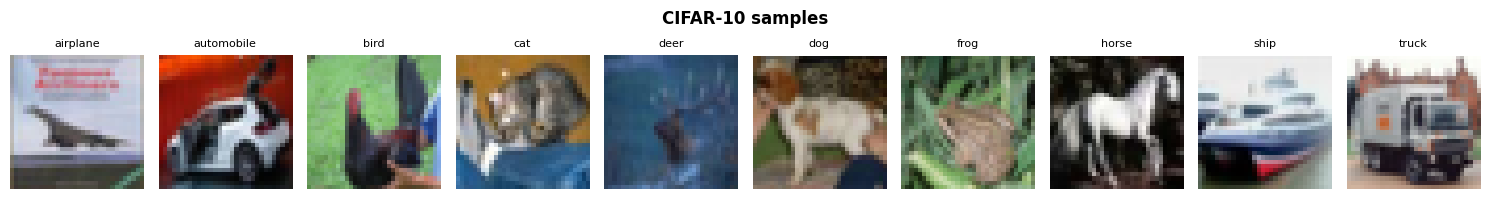

In [4]:
# === Данные: CIFAR-10 ===
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print(f"CIFAR-10 train: {x_train.shape}, test: {x_test.shape}")

# Показать примеры
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i in range(10):
    idx = np.where(y_test.flatten() == i)[0][0]
    axes[i].imshow(x_test[idx])
    axes[i].set_title(class_names[i], fontsize=8)
    axes[i].axis('off')
plt.suptitle('CIFAR-10 samples', fontweight='bold')
plt.tight_layout()
plt.show()

2026-04-06 18:08:29.471300: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-04-06 18:08:29.471325: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2026-04-06 18:08:29.471328: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
2026-04-06 18:08:29.471342: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-06 18:08:29.471351: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Parameters: 3,414,272
Epoch 1/20


2026-04-06 18:08:30.582239: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.0416 - val_loss: 0.0212
Epoch 2/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0223 - val_loss: 0.0241
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0200 - val_loss: 0.0181
Epoch 4/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0178 - val_loss: 0.0208
Epoch 5/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0173 - val_loss: 0.0196
Epoch 6/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0166 - val_loss: 0.0209
Epoch 7/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0161 - val_loss: 0.0162
Epoch 8/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0157 - val_loss: 0.0187
Epoch 9/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0157 - val_loss: 0.0151
Epoch 10/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0161 - val_loss: 0.0190
Epoch 11/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0165 - val_loss: 0.0150
Epoch 12/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/ste

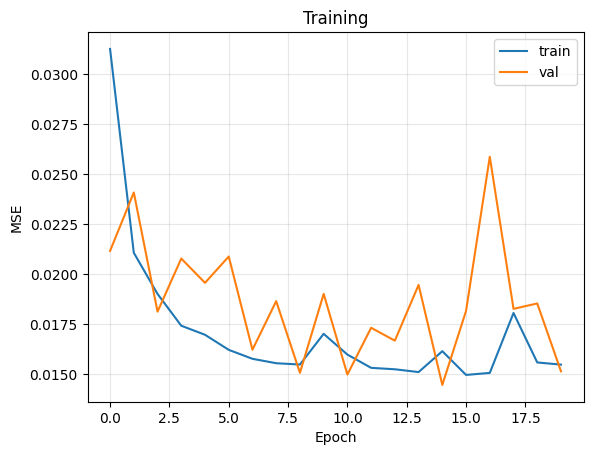

In [5]:
# === Обучение ===
np.random.seed(42)
tf.random.set_seed(42)

ae, encoder = build_color_ae()
print(f"Parameters: {ae.count_params():,}")

history = ae.fit(
    x_train, x_train,
    epochs=20,
    batch_size=256,
    validation_data=(x_test, x_test),
    verbose=1
)

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.title('Training')
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
# === Построить декодер ===
decoder_input = keras.Input(shape=(LATENT_DIM,))
x = decoder_input
found_latent = False
for layer in ae.layers:
    if layer.name == 'latent_ksparse':
        found_latent = True
        continue
    if found_latent:
        x = layer(x)
decoder = keras.Model(decoder_input, x)

# Получить латенты
all_latents = encoder.predict(x_test, verbose=0)
print(f"Latents shape: {all_latents.shape}")
print(f"Dead neurons: {np.sum(np.all(np.abs(all_latents) < 1e-6, axis=0))}/{LATENT_DIM}")

Latents shape: (10000, 256)
Dead neurons: 0/256


In [7]:
# === Функции сжатия ===

def apply_topk(latents, k):
    result = np.zeros_like(latents)
    for i in range(latents.shape[0]):
        top_idx = np.argsort(np.abs(latents[i]))[-k:]
        result[i, top_idx] = latents[i, top_idx]
    return result


def quantize(latents, bits):
    if bits >= 32:
        return latents
    result = np.zeros_like(latents)
    for i in range(latents.shape[0]):
        nz = np.where(np.abs(latents[i]) > 1e-10)[0]
        if len(nz) == 0:
            continue
        vals = latents[i, nz]
        vmin, vmax = vals.min(), vals.max()
        if vmax - vmin < 1e-10:
            result[i, nz] = vals
            continue
        levels = 2 ** bits - 1
        norm = (vals - vmin) / (vmax - vmin)
        q = np.round(norm * levels) / levels
        result[i, nz] = q * (vmax - vmin) + vmin
    return result


def compression_ratio(latent_dim, k, bits):
    original = latent_dim * 32
    index_bits = int(np.ceil(np.log2(latent_dim)))
    compressed = k * bits + k * index_bits + 2 * 32
    return original / compressed


def psnr(orig, recon):
    mse = np.mean((orig - recon) ** 2)
    if mse == 0:
        return float('inf')
    return 10 * np.log10(1.0 / mse)


print("Compression functions ready.")

Compression functions ready.


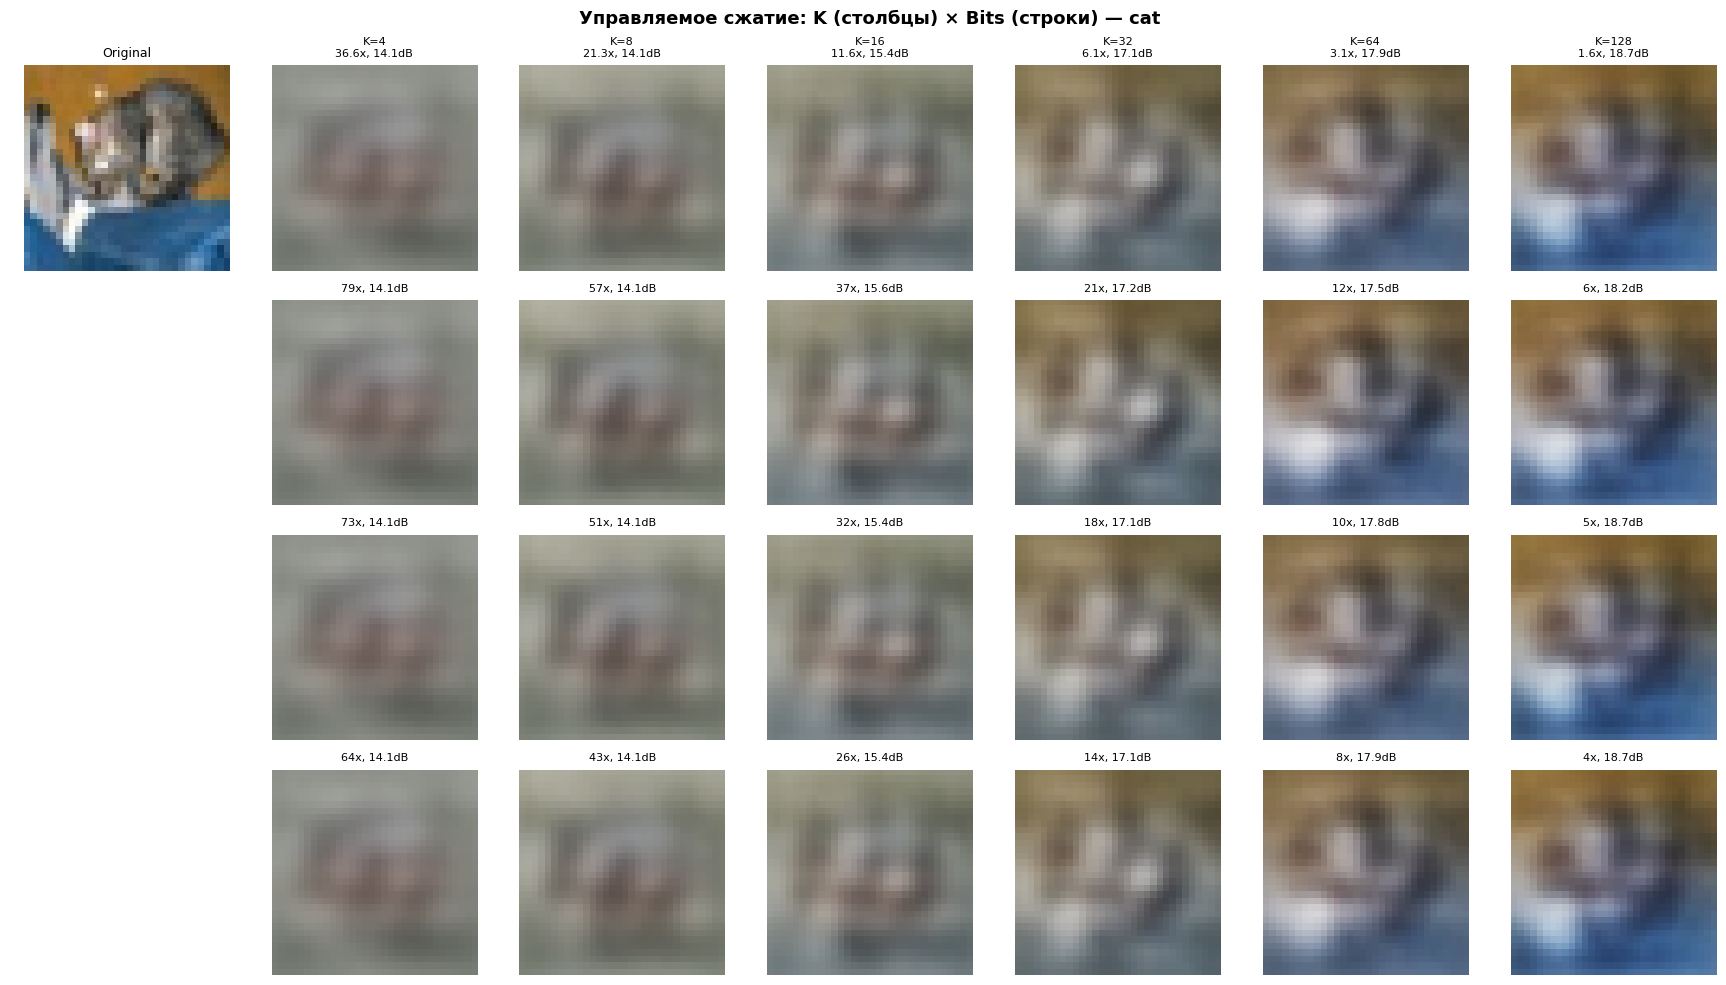

In [8]:
# === Демо: сжатие с разными K и битами ===

# Выбираем по одному изображению каждого класса
demo_indices = [np.where(y_test.flatten() == c)[0][0] for c in range(10)]
demo_images = x_test[demo_indices]
demo_latents = all_latents[demo_indices]

k_values = [4, 8, 16, 32, 64, 128]
bit_values = [2, 4, 8]

# Показать одно изображение при разных настройках
demo_idx = 3  # cat
orig = demo_images[demo_idx]
lat = demo_latents[demo_idx:demo_idx+1]

fig, axes = plt.subplots(len(bit_values) + 1, len(k_values) + 1,
                         figsize=(2.5 * (len(k_values) + 1), 2.5 * (len(bit_values) + 1)))

# Оригинал в левом верхнем углу
axes[0, 0].imshow(orig)
axes[0, 0].set_title('Original', fontsize=9)
axes[0, 0].axis('off')

# Первая строка: разные K без квантования
for j, k in enumerate(k_values):
    sparse = apply_topk(lat, k)
    recon = decoder.predict(sparse, verbose=0)[0]
    recon = np.clip(recon, 0, 1)
    cr = compression_ratio(LATENT_DIM, k, 32)
    p = psnr(orig, recon)
    axes[0, j+1].imshow(recon)
    axes[0, j+1].set_title(f'K={k}\n{cr:.1f}x, {p:.1f}dB', fontsize=8)
    axes[0, j+1].axis('off')
axes[0, 0].set_ylabel('32bit\n(no quant)', fontsize=9, rotation=0, labelpad=50)

# Остальные строки: разные bits
for i, bits in enumerate(bit_values, 1):
    axes[i, 0].axis('off')
    axes[i, 0].set_ylabel(f'{bits} bit', fontsize=9, rotation=0, labelpad=50)
    
    for j, k in enumerate(k_values):
        sparse = apply_topk(lat, k)
        q = quantize(sparse, bits)
        recon = decoder.predict(q, verbose=0)[0]
        recon = np.clip(recon, 0, 1)
        cr = compression_ratio(LATENT_DIM, k, bits)
        p = psnr(orig, recon)
        axes[i, j+1].imshow(recon)
        axes[i, j+1].set_title(f'{cr:.0f}x, {p:.1f}dB', fontsize=8)
        axes[i, j+1].axis('off')

plt.suptitle(f'Управляемое сжатие: K (столбцы) × Bits (строки) — {class_names[demo_idx]}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

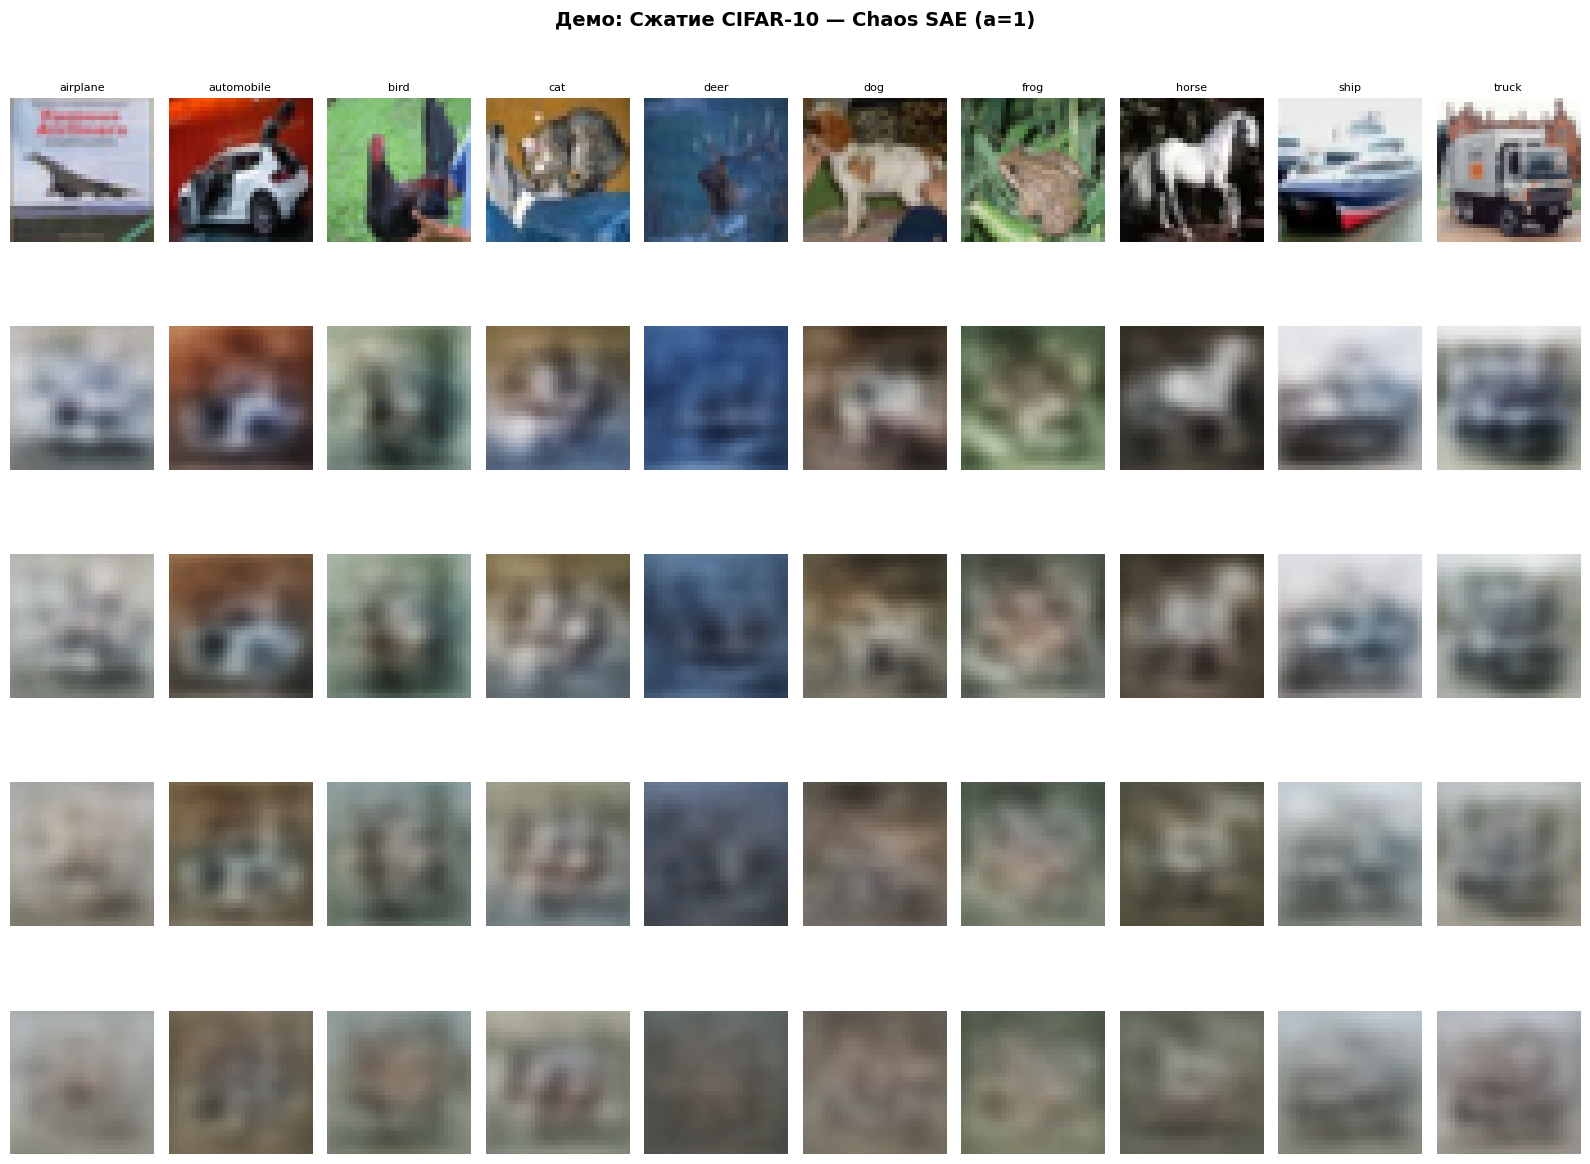

In [9]:
# === Все 10 классов при фиксированных настройках ===

settings = [
    ('Original', None, None),
    ('K=64, 8bit', 64, 8),
    ('K=32, 4bit', 32, 4),
    ('K=16, 4bit', 16, 4),
    ('K=8, 2bit', 8, 2),
]

fig, axes = plt.subplots(len(settings), 10, figsize=(16, 2.5 * len(settings)))

for row, (label, k, bits) in enumerate(settings):
    for col in range(10):
        if k is None:
            axes[row, col].imshow(demo_images[col])
        else:
            lat = demo_latents[col:col+1]
            sparse = apply_topk(lat, k)
            q = quantize(sparse, bits)
            recon = decoder.predict(q, verbose=0)[0]
            recon = np.clip(recon, 0, 1)
            axes[row, col].imshow(recon)
        
        if row == 0:
            axes[row, col].set_title(class_names[col], fontsize=8)
        axes[row, col].axis('off')
    
    if k is not None:
        cr = compression_ratio(LATENT_DIM, k, bits)
        axes[row, 0].set_ylabel(f'{label}\n{cr:.0f}x', fontsize=8, rotation=0, labelpad=70)
    else:
        axes[row, 0].set_ylabel(label, fontsize=8, rotation=0, labelpad=70)

plt.suptitle('Демо: Сжатие CIFAR-10 — Chaos SAE (a=1)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Считаем rate-distortion...
  K=  4,  2bit: mse=0.0481, psnr=13.2dB, 78.8x
  K=  4,  4bit: mse=0.0481, psnr=13.2dB, 73.1x
  K=  4,  8bit: mse=0.0481, psnr=13.2dB, 64.0x
  K=  4, 32bit: mse=0.0481, psnr=13.2dB, 36.6x
  K=  8,  2bit: mse=0.0395, psnr=14.0dB, 56.9x
  K=  8,  4bit: mse=0.0396, psnr=14.0dB, 51.2x
  K=  8,  8bit: mse=0.0398, psnr=14.0dB, 42.7x
  K=  8, 32bit: mse=0.0398, psnr=14.0dB, 21.3x
  K= 16,  2bit: mse=0.0300, psnr=15.2dB, 36.6x
  K= 16,  4bit: mse=0.0306, psnr=15.1dB, 32.0x
  K= 16,  8bit: mse=0.0306, psnr=15.1dB, 25.6x
  K= 16, 32bit: mse=0.0306, psnr=15.1dB, 11.6x
  K= 32,  2bit: mse=0.0217, psnr=16.6dB, 21.3x
  K= 32,  4bit: mse=0.0223, psnr=16.5dB, 18.3x
  K= 32,  8bit: mse=0.0224, psnr=16.5dB, 14.2x
  K= 32, 32bit: mse=0.0224, psnr=16.5dB, 6.1x
  K= 64,  2bit: mse=0.0170, psnr=17.7dB, 11.6x
  K= 64,  4bit: mse=0.0170, psnr=17.7dB, 9.8x
  K= 64,  8bit: mse=0.0170, psnr=17.7dB, 7.5x
  K= 64, 32bit: mse=0.0170, psnr=17.7dB, 3.1x
  K=128,  2bit: mse=0.0154, psnr=18.1

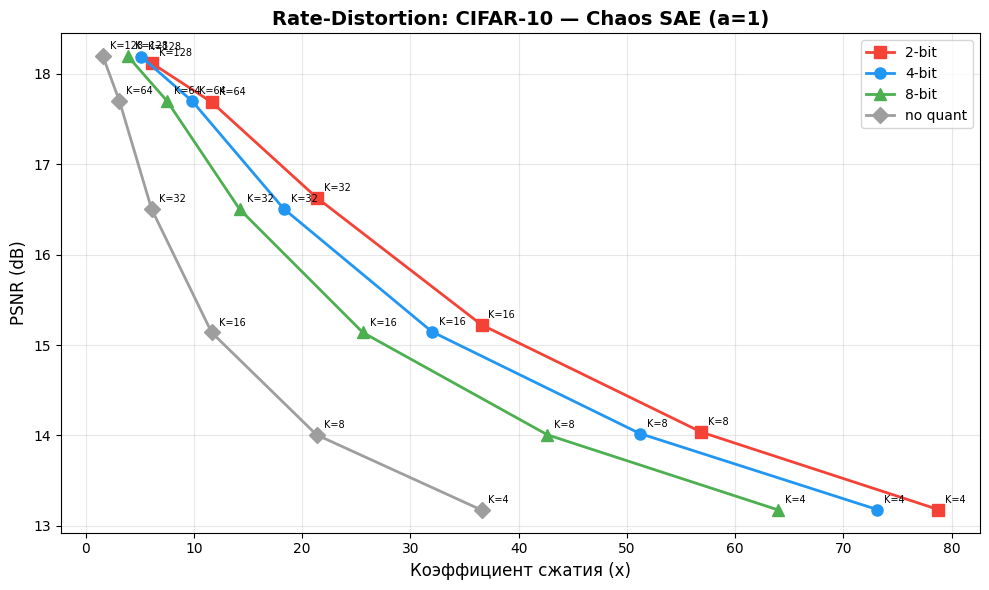

Done.


In [10]:
# === Rate-Distortion на всём тестовом наборе ===

print("Считаем rate-distortion...")
rd_results = []

for k in [4, 8, 16, 32, 64, 128]:
    sparse = apply_topk(all_latents, k)
    for bits in [2, 4, 8, 32]:
        q = quantize(sparse, bits)
        recon = decoder.predict(q, verbose=0)
        recon = np.clip(recon, 0, 1)
        mse = float(np.mean((x_test - recon) ** 2))
        p = float(psnr(x_test, recon))
        cr = compression_ratio(LATENT_DIM, k, bits)
        rd_results.append({'k': k, 'bits': bits, 'mse': mse, 'psnr': p, 'cr': cr})
        print(f"  K={k:>3}, {bits:>2}bit: mse={mse:.4f}, psnr={p:.1f}dB, {cr:.1f}x")

# График
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
bit_colors = {2: '#F44336', 4: '#2196F3', 8: '#4CAF50', 32: '#9E9E9E'}
bit_markers = {2: 's', 4: 'o', 8: '^', 32: 'D'}

for bits in [2, 4, 8, 32]:
    pts = [r for r in rd_results if r['bits'] == bits]
    crs = [r['cr'] for r in pts]
    psnrs = [r['psnr'] for r in pts]
    label = f'{bits}-bit' if bits < 32 else 'no quant'
    ax.plot(crs, psnrs, color=bit_colors[bits], marker=bit_markers[bits],
            linewidth=2, markersize=8, label=label)
    for r in pts:
        ax.annotate(f'K={r["k"]}', (r['cr'], r['psnr']),
                   textcoords="offset points", xytext=(5, 5), fontsize=7)

ax.set_xlabel('Коэффициент сжатия (x)', fontsize=12)
ax.set_ylabel('PSNR (dB)', fontsize=12)
ax.set_title('Rate-Distortion: CIFAR-10 — Chaos SAE (a=1)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Done.")